In [1]:
import pandas as pd
market_df = pd.read_csv("prices_round_1_day_0.csv", sep=';')
trades_df = pd.read_csv("trades_round_1_day_0.csv", sep=';')

market_df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0
3,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0
4,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0


In [2]:
trades_df.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,12007.0,5
1,3300,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,12010.0,7
2,4100,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11998.0,6
3,6300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5
4,6800,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,12000.0,5


In [3]:
market_df = market_df[market_df['product'] == "ASH_COATED_OSMIUM"]
trades_df = trades_df[trades_df['symbol'] == "ASH_COATED_OSMIUM"]

In [4]:
market_df = market_df.rename(columns={"bid_price_1":"bp1", "bid_price_2":"bp2", "bid_volume_1": "bv1", "bid_volume_2": "bv2", "ask_price_1": "ap1", "ask_price_2": "ap2", "ask_volume_1": "av1", "ask_volume_2": "av2"})

In [5]:
# Feature Engineering
market_df['ap1-bp1'] = market_df['ap1'] - market_df['bp1']
market_df['ap2-bp2'] = market_df['ap2'] - market_df['bp2']
market_df['bp1-bp2'] = market_df['bp1'] - market_df['bp2']
market_df['ap2-ap1'] = market_df['ap2'] - market_df['ap1']
market_df['(bp1-bp2)-(ap2-ap2)'] = market_df['bp1-bp2'] - market_df['ap2-ap1']
market_df['bv1+bv2'] = market_df['bv1'] + market_df['bv2']
market_df['av1+av2'] = market_df['av1'] + market_df['av2']
market_df['(bv1+bv2)-(av1+av2)'] = market_df['bv1+bv2'] - market_df['av1+av2']


In [6]:
market_df.head()

,day,timestamp,product,bp1,bv1,bp2,bv2,bid_price_3,bid_volume_3,ap1,...,mid_price,profit_and_loss,ap1-bp1,ap2-bp2,bp1-bp2,ap2-ap1,(bp1-bp2)-(ap2-ap2),bv1+bv2,av1+av2,(bv1+bv2)-(av1+av2)
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,...,10013.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,...,10003.0,0.0,16.0,NaN,NaN,2.0,NaN,NaN,43.0,NaN
5,0,200,ASH_COATED_OSMIUM,9994.0,13.0,9992.0,21.0,NaN,NaN,10013.0,...,10003.5,0.0,19.0,NaN,2.0,NaN,NaN,34.0,NaN,NaN
6,0,300,ASH_COATED_OSMIUM,9994.0,11.0,9992.0,23.0,NaN,NaN,10010.0,...,10002.0,0.0,16.0,21.0,2.0,3.0,-1.0,34.0,34.0,0.0
8,0,400,ASH_COATED_OSMIUM,9994.0,13.0,9991.0,23.0,NaN,NaN,10010.0,...,10002.0,0.0,16.0,21.0,3.0,2.0,1.0,36.0,36.0,0.0


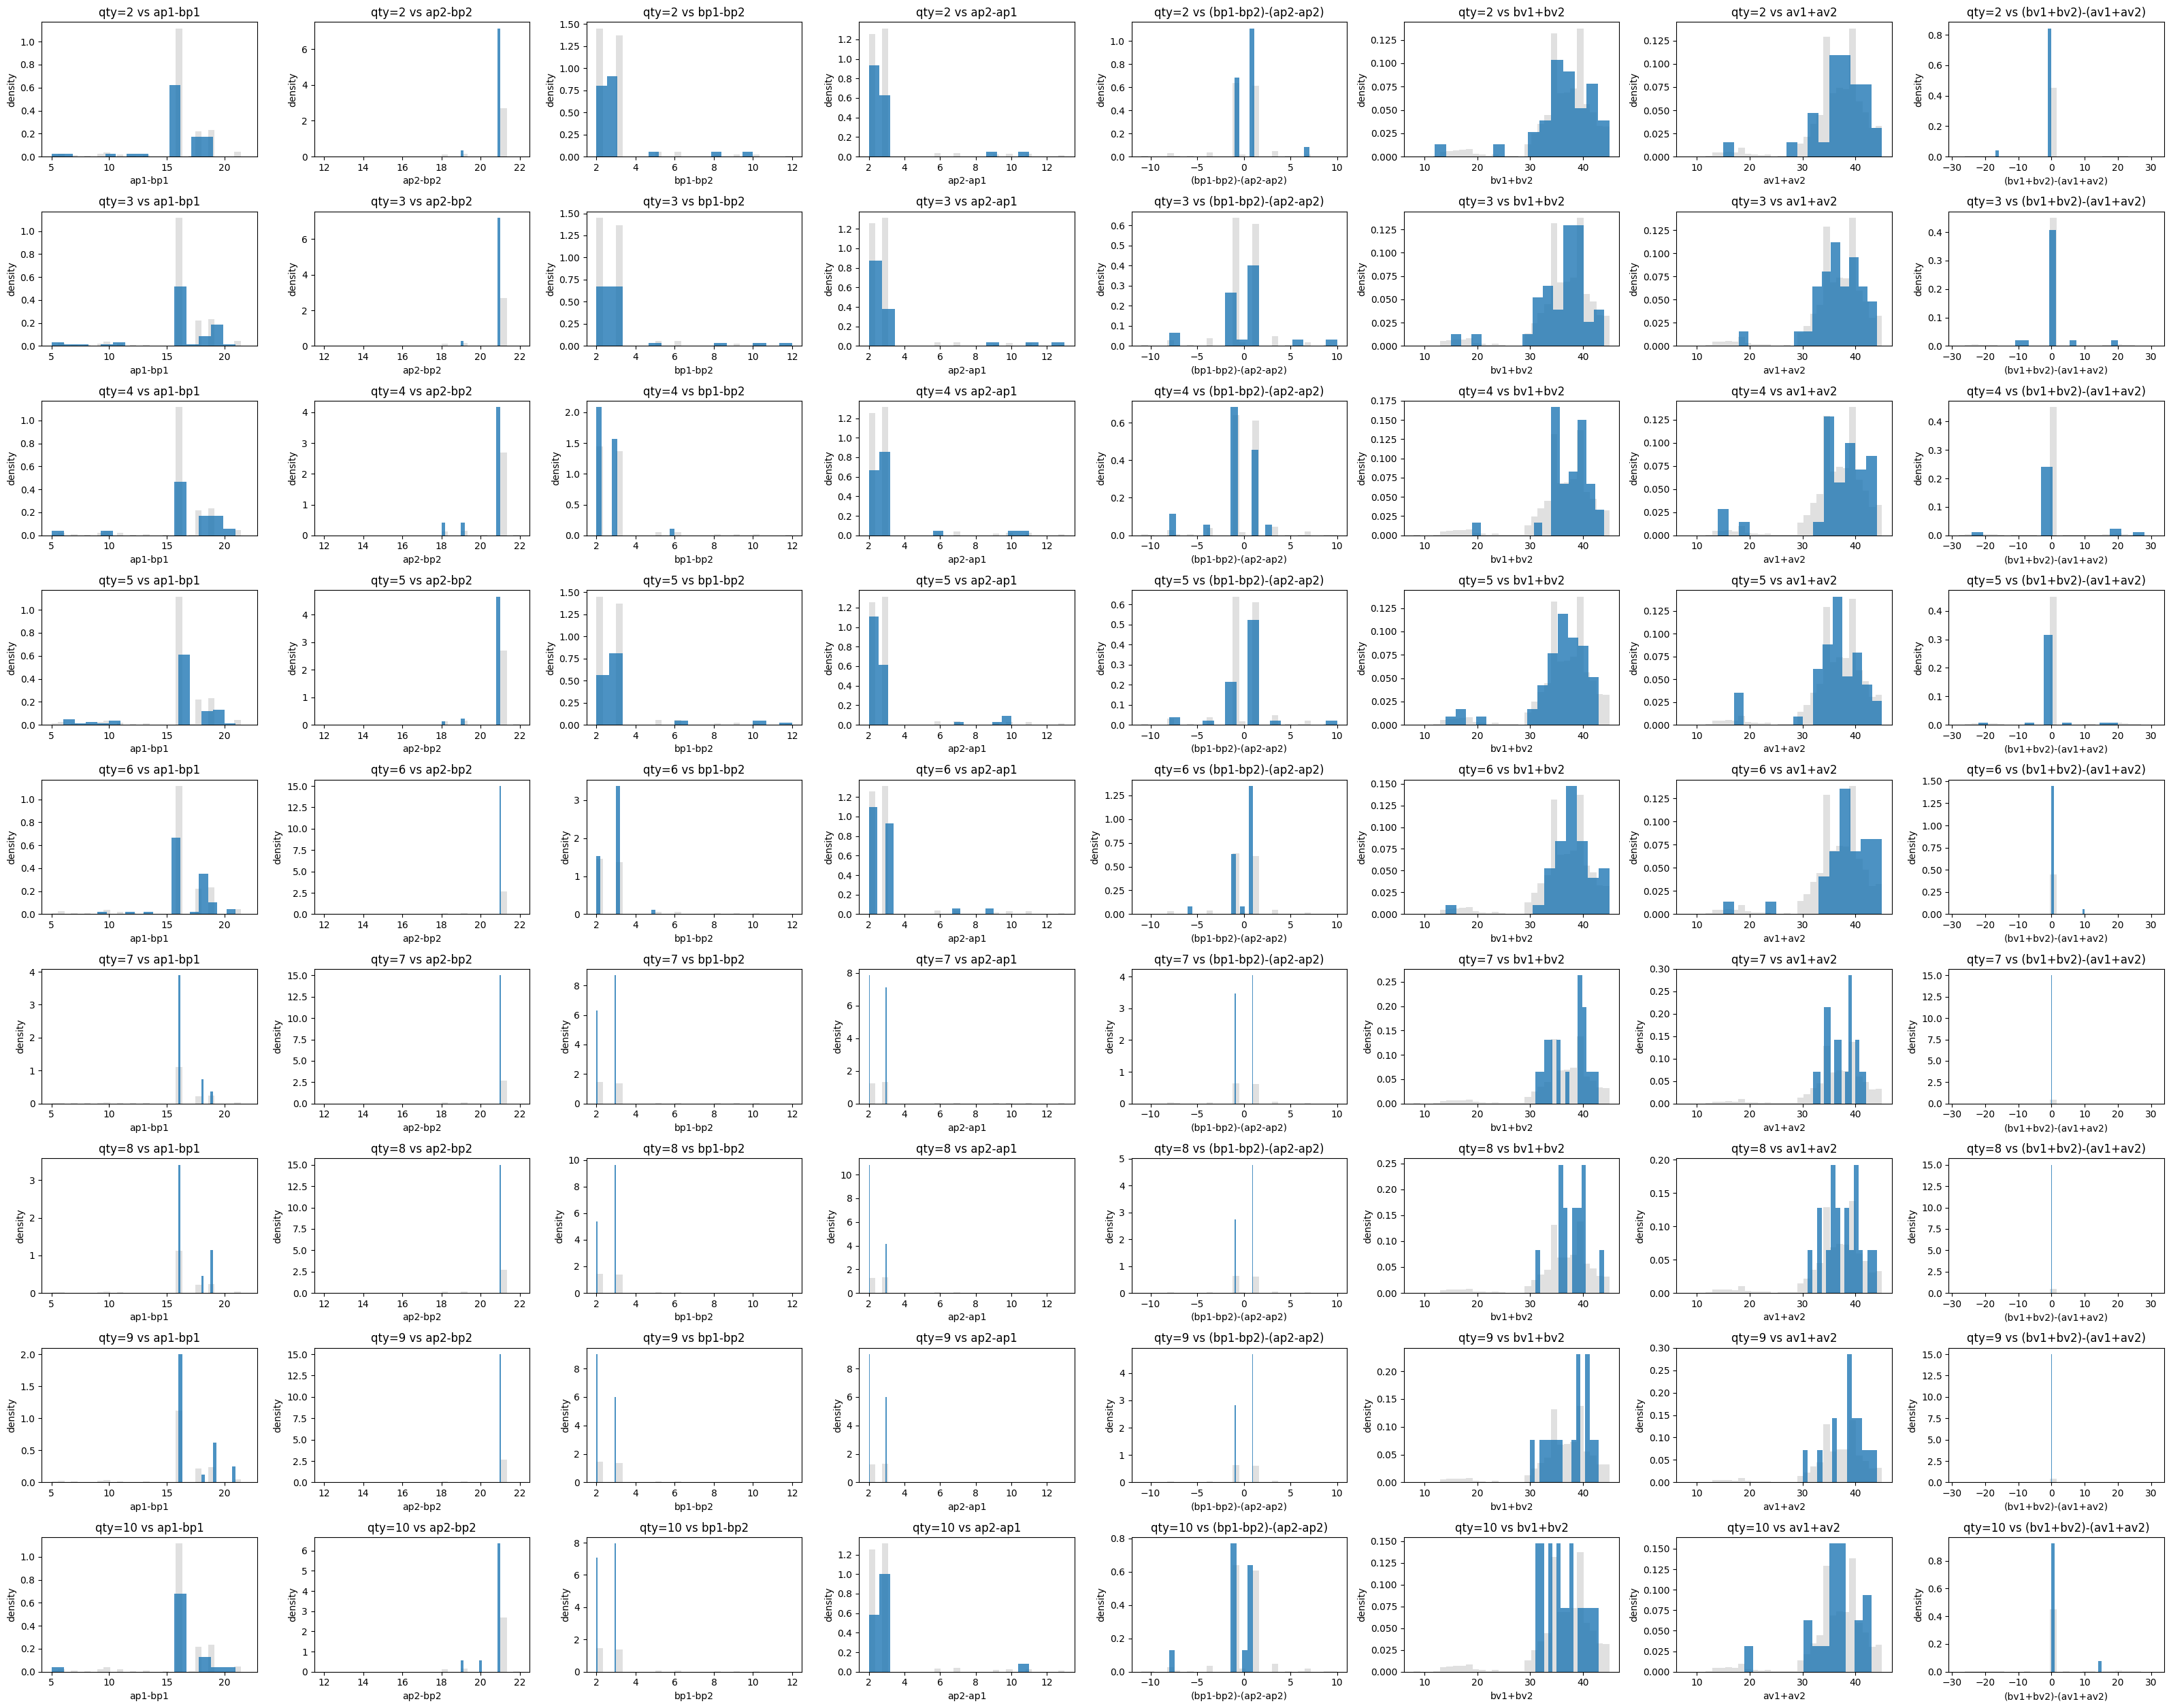

In [7]:
import matplotlib.pyplot as plt

market_feature_cols = [
    # 'bp1', 'bp2', 'ap1', 'ap2', 'bv1', 'bv2', 'av1', 'av2', 'mid_price',
    'ap1-bp1', 'ap2-bp2', 'bp1-bp2', 'ap2-ap1',
    '(bp1-bp2)-(ap2-ap2)', 'bv1+bv2', 'av1+av2', '(bv1+bv2)-(av1+av2)'
]
market_feature_cols = [col for col in market_feature_cols if col in market_df.columns]

quantity_clusters = sorted(trades_df['quantity'].dropna().unique())

trade_feature_df = trades_df[['timestamp', 'price', 'quantity']].merge(
    market_df[['timestamp'] + market_feature_cols],
    on='timestamp',
    how='inner'
)

n_rows = len(quantity_clusters)
n_cols = len(market_feature_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 2.8 * n_rows),
    squeeze=False
)

for row_idx, quantity in enumerate(quantity_clusters):
    cluster_df = trade_feature_df[trade_feature_df['quantity'] == quantity]

    for col_idx, feature in enumerate(market_feature_cols):
        ax = axes[row_idx][col_idx]
        feature_market = market_df[feature].dropna()
        feature_cluster = cluster_df[feature].dropna()

        if feature_market.empty:
            ax.set_visible(False)
            continue

        ax.hist(feature_market, bins=30, color='lightgray', alpha=0.7, density=True)

        if not feature_cluster.empty:
            ax.hist(feature_cluster, bins=15, color='tab:blue', alpha=0.8, density=True)
        else:
            ax.text(0.5, 0.5, 'No trades', ha='center', va='center', transform=ax.transAxes)

        ax.set_title(f'qty={quantity} vs {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('density')

plt.tight_layout()
plt.show()


In [14]:
bvav_equal_market = market_df[abs(market_df['(bv1+bv2)-(av1+av2)']) < 5]

In [15]:
bvav_equal_market.head()

,day,timestamp,product,bp1,bv1,bp2,bv2,bid_price_3,bid_volume_3,ap1,...,mid_price,profit_and_loss,ap1-bp1,ap2-bp2,bp1-bp2,ap2-ap1,(bp1-bp2)-(ap2-ap2),bv1+bv2,av1+av2,(bv1+bv2)-(av1+av2)
6,0,300,ASH_COATED_OSMIUM,9994.0,11.0,9992.0,23.0,NaN,NaN,10010.0,...,10002.0,0.0,16.0,21.0,2.0,3.0,-1.0,34.0,34.0,0.0
8,0,400,ASH_COATED_OSMIUM,9994.0,13.0,9991.0,23.0,NaN,NaN,10010.0,...,10002.0,0.0,16.0,21.0,3.0,2.0,1.0,36.0,36.0,0.0
11,0,500,ASH_COATED_OSMIUM,9994.0,12.0,9991.0,22.0,NaN,NaN,10010.0,...,10002.0,0.0,16.0,21.0,3.0,2.0,1.0,34.0,34.0,0.0
19,0,900,ASH_COATED_OSMIUM,9992.0,11.0,9990.0,27.0,NaN,NaN,10008.0,...,10000.0,0.0,16.0,21.0,2.0,3.0,-1.0,38.0,38.0,0.0
21,0,1000,ASH_COATED_OSMIUM,9993.0,12.0,9990.0,26.0,NaN,NaN,10009.0,...,10001.0,0.0,16.0,21.0,3.0,2.0,1.0,38.0,38.0,0.0


In [16]:
len(trades_df)

411

In [19]:
balanced_market_trades = trades_df.merge(
    bvav_equal_market[[
        'timestamp', 'bp1', 'bp2', 'ap1', 'ap2',
        'bv1', 'bv2', 'av1', 'av2',
        'bv1+bv2', 'av1+av2', '(bv1+bv2)-(av1+av2)'
    ]],
    on='timestamp',
    how='inner'
).sort_values(['timestamp', 'price', 'quantity']).reset_index(drop=True)

print(f"Matched trades: {len(balanced_market_trades)}")
print(f"Unique balanced timestamps with trades: {balanced_market_trades['timestamp'].nunique()}")
print("\nQuantity counts:")
print(balanced_market_trades['quantity'].value_counts().sort_index())
print(trades_df['quantity'].value_counts().sort_index())

balanced_market_trades


Matched trades: 170
Unique balanced timestamps with trades: 169

Quantity counts:
quantity
2     21
3     21
4     20
5     38
6     26
7     13
8     11
9      8
10    12
Name: count, dtype: int64
quantity
2     50
3     56
4     53
5     87
6     61
7     31
8     22
9     26
10    25
Name: count, dtype: int64


,timestamp,buyer,seller,symbol,currency,price,quantity,bp1,bp2,ap1,ap2,bv1,bv2,av1,av2,bv1+bv2,av1+av2,(bv1+bv2)-(av1+av2)
0,6300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5,9993.0,9990.0,10009.0,10011.0,12.0,25.0,12.0,25.0,37.0,37.0,0.0
1,7000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,4,9992.0,9990.0,10008.0,10011.0,11.0,27.0,11.0,27.0,38.0,38.0,0.0
2,7100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,3,9992.0,9990.0,10008.0,10011.0,15.0,29.0,15.0,29.0,44.0,44.0,0.0
3,9300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9992.0,7,9992.0,9989.0,10008.0,10010.0,10.0,23.0,10.0,23.0,33.0,33.0,0.0
4,17700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5,9993.0,9990.0,10009.0,10011.0,13.0,23.0,13.0,23.0,36.0,36.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,974300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10018.0,4,10002.0,9999.0,10018.0,10020.0,12.0,29.0,12.0,29.0,41.0,41.0,0.0
166,980200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10000.0,4,10000.0,9998.0,10016.0,10019.0,10.0,24.0,10.0,24.0,34.0,34.0,0.0
167,987400,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10016.0,9,10000.0,9997.0,10016.0,10018.0,10.0,20.0,10.0,20.0,30.0,30.0,0.0
168,991600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10018.0,5,10002.0,9999.0,10018.0,10020.0,11.0,23.0,11.0,23.0,34.0,34.0,0.0


In [18]:
balanced_market_trades.head(20)

,timestamp,buyer,seller,symbol,currency,price,quantity,bp1,bp2,ap1,ap2,bv1,bv2,av1,av2,bv1+bv2,av1+av2,(bv1+bv2)-(av1+av2)
0,6300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5,9993.0,9990.0,10009.0,10011.0,12.0,25.0,12.0,25.0,37.0,37.0,0.0
1,7000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,4,9992.0,9990.0,10008.0,10011.0,11.0,27.0,11.0,27.0,38.0,38.0,0.0
2,7100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,3,9992.0,9990.0,10008.0,10011.0,15.0,29.0,15.0,29.0,44.0,44.0,0.0
3,9300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9992.0,7,9992.0,9989.0,10008.0,10010.0,10.0,23.0,10.0,23.0,33.0,33.0,0.0
4,17700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5,9993.0,9990.0,10009.0,10011.0,13.0,23.0,13.0,23.0,36.0,36.0,0.0
5,23200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9993.0,6,9993.0,9990.0,10009.0,10011.0,12.0,26.0,12.0,26.0,38.0,38.0,0.0
6,30100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5,9993.0,9991.0,10009.0,10012.0,10.0,22.0,10.0,22.0,32.0,32.0,0.0
7,31500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9993.0,10,9993.0,9990.0,10009.0,10011.0,15.0,23.0,15.0,23.0,38.0,38.0,0.0
8,37300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,7,9992.0,9989.0,10008.0,10010.0,13.0,27.0,13.0,27.0,40.0,40.0,0.0
9,40500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,8,9993.0,9990.0,10009.0,10011.0,13.0,24.0,13.0,24.0,37.0,37.0,0.0
